# 📊 Phase 1 – Advanced Evaluation Metrics
**Goal:** Go beyond accuracy. Learn *when* and *why* to use each metric.

Topics covered:
- Precision-Recall vs ROC-AUC tradeoffs
- F1 / F-beta scores
- Log Loss & Brier Score (probability calibration)
- Matthews Correlation Coefficient
- Multi-class metrics: Macro vs Micro vs Weighted


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    log_loss, brier_score_loss, matthews_corrcoef,
    f1_score, average_precision_score
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [8]:
# ── Create imbalanced dataset (common in real-world) ──
X, y = make_classification(
    n_samples=5000, n_features=20, n_informative=10,
    weights=[0.85, 0.15],  # 85% class 0, 15% class 1 – imbalanced!
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'Class distribution in test: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train size: (4000, 20), Test size: (1000, 20)
Class distribution in test: {0: 846, 1: 154}


In [9]:
# ── Train 3 models to compare ──
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f'\n📌 {name}')
    print(classification_report(y_test, y_pred, target_names=['Majority', 'Minority']))


📌 Logistic Regression
              precision    recall  f1-score   support

    Majority       0.94      0.98      0.96       846
    Minority       0.84      0.63      0.72       154

    accuracy                           0.93      1000
   macro avg       0.89      0.80      0.84      1000
weighted avg       0.92      0.93      0.92      1000


📌 Random Forest
              precision    recall  f1-score   support

    Majority       0.95      1.00      0.97       846
    Minority       0.96      0.71      0.82       154

    accuracy                           0.95      1000
   macro avg       0.96      0.85      0.90      1000
weighted avg       0.95      0.95      0.95      1000


📌 Gradient Boosting
              precision    recall  f1-score   support

    Majority       0.95      0.99      0.97       846
    Minority       0.91      0.69      0.79       154

    accuracy                           0.94      1000
   macro avg       0.93      0.84      0.88      1000
weighted avg 

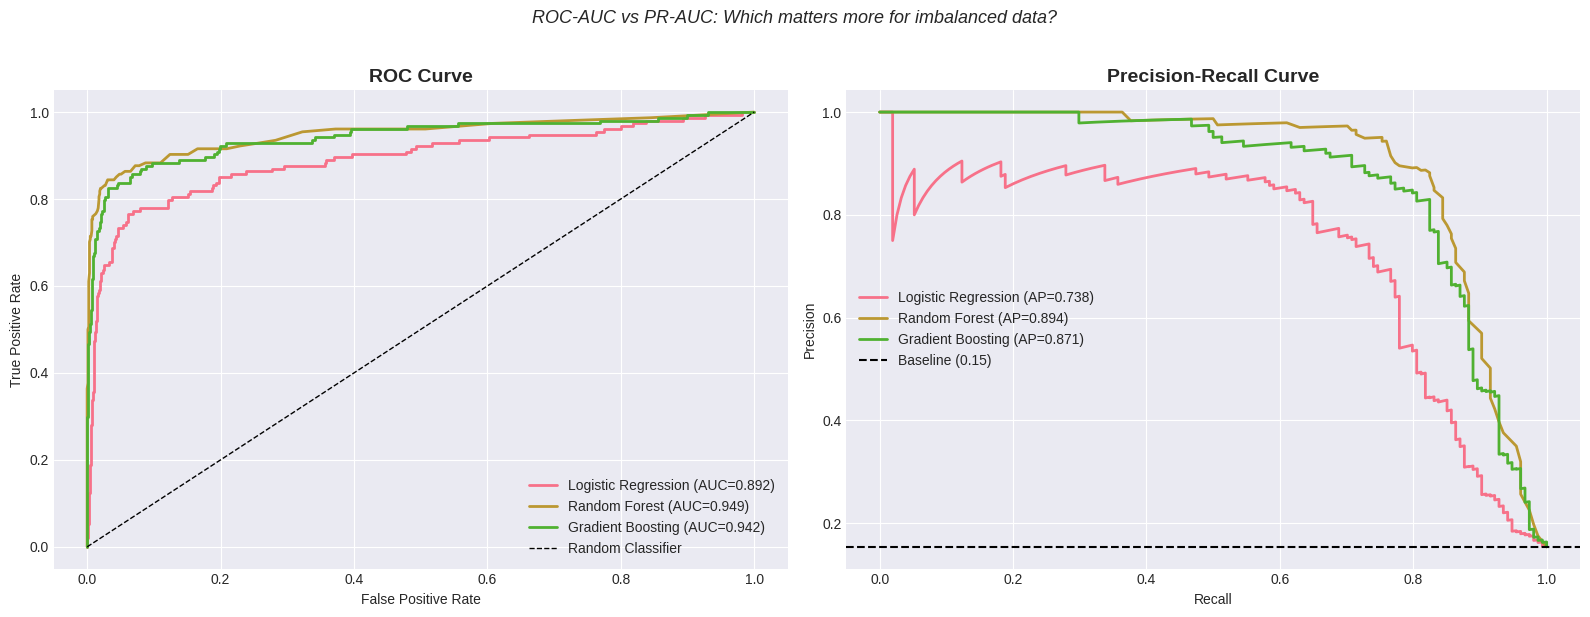

💡 Notice: PR curves reveal model performance differences better for minority class!


In [10]:
# ── ROC-AUC vs Precision-Recall ──
# KEY INSIGHT: With imbalanced data, PR-AUC is more informative!

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curve
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(rec, prec, lw=2, label=f'{name} (AP={ap:.3f})')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend()

plt.suptitle('ROC-AUC vs PR-AUC: Which matters more for imbalanced data?', 
             fontsize=13, y=1.02, style='italic')
plt.tight_layout()
plt.savefig('../data/phase1_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Notice: PR curves reveal model performance differences better for minority class!')

In [12]:
# ── Comprehensive Metrics Comparison Table ──
metrics_table = []
for name, res in results.items():
    y_pred, y_prob = res['y_pred'], res['y_prob']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    metrics_table.append({
        'Model': name,
        'Accuracy': (y_pred == y_test).mean().round(4),
        'F1 (Minority)': f1_score(y_test, y_pred, pos_label=1).round(4),
        'F1 (Macro)': f1_score(y_test, y_pred, average='macro').round(4),
        'ROC-AUC': auc(fpr, tpr).round(4),
        'PR-AUC': average_precision_score(y_test, y_prob).round(4),
        'Log Loss': log_loss(y_test, y_prob).round(4),
        'Brier Score': brier_score_loss(y_test, y_prob).round(4),
        'MCC': matthews_corrcoef(y_test, y_pred).round(4),
    })

df_metrics = pd.DataFrame(metrics_table).set_index('Model')
print('\n🏆 Comprehensive Metrics Comparison:')
display(df_metrics.style.highlight_max(color='lightgreen').highlight_min(subset=['Log Loss', 'Brier Score'], color='lightgreen'))


🏆 Comprehensive Metrics Comparison:


,Accuracy,F1 (Minority),F1 (Macro),ROC-AUC,PR-AUC,Log Loss,Brier Score,MCC
Model,,,,,,,,
Logistic Regression,0.925000,0.721200,0.838900,0.891600,0.737500,0.251800,0.066000,0.688600
Random Forest,0.952000,0.820900,0.896600,0.949000,0.893800,0.238700,0.045000,0.805900
Gradient Boosting,0.943000,0.789700,0.878400,0.941700,0.871200,0.172900,0.045800,0.767000


## 🧠 Key Takeaways

| Metric | Use When |
|--------|----------|
| **Accuracy** | Balanced classes only |
| **F1 Score** | Imbalanced + you care about false negatives |
| **ROC-AUC** | Comparing models, not threshold-sensitive |
| **PR-AUC** | Imbalanced data, minority class is the 'positive' |
| **Log Loss** | Probability calibration quality |
| **Brier Score** | Similar to Log Loss, more interpretable |
| **MCC** | Single balanced metric for any class distribution |

## 🎯 Exercise
Try changing `weights=[0.85, 0.15]` to `[0.99, 0.01]` (extreme imbalance) and observe how Accuracy becomes completely misleading!